# Benchmark Analysis

This notebook analyzes bundled benchmark results from `results/benchmark`. The main input is the campaign-level `dataset_benchmark_metrics.csv`, with optional drilldown into manifests if needed.

## Configuration

Change `CAMPAIGNS_ROOT` if later result bundles are written to a different folder or contain more seeds.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 160)


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
BENCHMARK_ROOT = REPO_ROOT / 'results' / 'benchmark'
CAMPAIGNS_ROOT = BENCHMARK_ROOT / 'campaigns'
EXPERIMENTS_ROOT = BENCHMARK_ROOT / 'experiments'

print('REPO_ROOT:', REPO_ROOT)
print('CAMPAIGNS_ROOT:', CAMPAIGNS_ROOT)
print('EXPERIMENTS_ROOT:', EXPERIMENTS_ROOT)

REPO_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems
CAMPAIGNS_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/benchmark/campaigns
EXPERIMENTS_ROOT: /Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/results/benchmark/experiments


## Load Campaign Metrics

Each campaign folder contains a compact metrics CSV with one row per `method × dataset_seed`. That is the primary analysis input.

In [2]:
METHOD_ORDER = ['lhs_static', 'qbc_deep_ensemble', 'marker_directed', 'qbc_marker_hybrid']


def pretty_campaign_label(name: str) -> str:
    return name.replace('benchmark_', '').replace('_', ' ')


def load_campaign_metrics(campaigns_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    records = []
    inventory_rows = []
    for campaign_dir in sorted(campaigns_root.glob('benchmark_*')):
        metrics_path = campaign_dir / 'dataset_benchmark_metrics.csv'
        manifest_path = campaign_dir / 'campaign_manifest.json'
        if not metrics_path.exists() or not manifest_path.exists():
            continue

        manifest = json.loads(manifest_path.read_text())
        campaign_meta = manifest.get('campaign', {})
        campaign_name = str(campaign_meta.get('name', campaign_dir.name))
        experiment_id = str(campaign_meta.get('experiment_id', ''))
        preset = str(campaign_meta.get('preset', ''))

        df = pd.read_csv(metrics_path)
        df['campaign_dir'] = campaign_dir.name
        df['campaign_name'] = campaign_name
        df['campaign_label'] = pretty_campaign_label(campaign_name)
        df['experiment_id'] = experiment_id
        df['preset'] = preset
        records.append(df)

        inventory_rows.append(
            {
                'campaign_dir': campaign_dir.name,
                'campaign_name': campaign_name,
                'campaign_label': pretty_campaign_label(campaign_name),
                'experiment_id': experiment_id,
                'preset': preset,
                'n_rows': len(df),
                'n_methods': df['method'].nunique(),
                'n_dataset_seeds': df['dataset_seed'].nunique(),
                'methods': ', '.join(sorted(df['method'].unique())),
                'dataset_seeds': ', '.join(sorted(df['dataset_seed'].unique())),
                'budgets': ', '.join(sorted(df['budget'].astype(str).unique())),
            }
        )

    if not records:
        raise FileNotFoundError(f'No benchmark campaign metrics found under {campaigns_root}')

    metrics = pd.concat(records, ignore_index=True)
    metrics['method'] = pd.Categorical(metrics['method'], categories=METHOD_ORDER, ordered=True)
    inventory = pd.DataFrame(inventory_rows).sort_values('campaign_name').reset_index(drop=True)
    return metrics, inventory


benchmark_df, campaign_inventory = load_campaign_metrics(CAMPAIGNS_ROOT)
display(campaign_inventory)
display(benchmark_df.head())

,campaign_dir,campaign_name,campaign_label,experiment_id,preset,n_rows,n_methods,n_dataset_seeds,methods,dataset_seeds,budgets
0,benchmark_sm4_8k_20260312_034801,benchmark_sm4_8k,sm4 8k,thesis_sm4_benchmark_sm4_8k_v1,default,20,4,5,"lhs_static, marker_directed, qbc_deep_ensemble, qbc_marker_hybrid","ds01, ds02, ds03, ds04, ds05",b8192
1,benchmark_sm6_8k_20260311_103853,benchmark_sm6_8k,sm6 8k,thesis_sm6_benchmark_8k_v1,default,20,4,5,"lhs_static, marker_directed, qbc_deep_ensemble, qbc_marker_hybrid","ds01, ds02, ds03, ds04, ds05",b8192
2,benchmark_sm_avr_gov_8k_20260311_104334,benchmark_sm_avr_gov_8k,sm avr gov 8k,thesis_sm6_benchmark_sm_avr_gov_8k_v1,default,20,4,5,"lhs_static, marker_directed, qbc_deep_ensemble, qbc_marker_hybrid","ds01, ds02, ds03, ds04, ds05",b8192


,method,budget,dataset_seed,mse_mean,mse_std,rmse_mean,rmse_std,campaign_dir,campaign_name,campaign_label,experiment_id,preset
0,lhs_static,b8192,ds01,0.000117,0.000046,0.010668,0.002117,benchmark_sm4_8k_20260312_034801,benchmark_sm4_8k,sm4 8k,thesis_sm4_benchmark_sm4_8k_v1,default
1,lhs_static,b8192,ds02,0.000130,0.000022,0.011356,0.000961,benchmark_sm4_8k_20260312_034801,benchmark_sm4_8k,sm4 8k,thesis_sm4_benchmark_sm4_8k_v1,default
2,lhs_static,b8192,ds03,0.000245,0.000067,0.015540,0.002202,benchmark_sm4_8k_20260312_034801,benchmark_sm4_8k,sm4 8k,thesis_sm4_benchmark_sm4_8k_v1,default
3,lhs_static,b8192,ds04,0.000197,0.000065,0.013913,0.002338,benchmark_sm4_8k_20260312_034801,benchmark_sm4_8k,sm4 8k,thesis_sm4_benchmark_sm4_8k_v1,default
4,lhs_static,b8192,ds05,0.000157,0.000062,0.012364,0.002596,benchmark_sm4_8k_20260312_034801,benchmark_sm4_8k,sm4 8k,thesis_sm4_benchmark_sm4_8k_v1,default


## Campaign Inventory

This confirms what is present in the current bundle before any analysis is done.

In [3]:
inventory_summary = pd.DataFrame(
    {
        'n_campaigns': [benchmark_df['campaign_name'].nunique()],
        'methods': [', '.join([m for m in METHOD_ORDER if m in benchmark_df['method'].astype(str).unique()])],
        'dataset_seeds_total': [benchmark_df['dataset_seed'].nunique()],
        'budgets': [', '.join(sorted(benchmark_df['budget'].astype(str).unique()))],
    }
)
display(inventory_summary)

,n_campaigns,methods,dataset_seeds_total,budgets
0,3,"lhs_static, qbc_deep_ensemble, marker_directed, qbc_marker_hybrid",5,b8192


## Per-Campaign Main Tables

For each campaign, the main table aggregates over dataset seeds and ranks methods by mean RMSE.

In [4]:
campaign_method_summary = (
    benchmark_df.groupby(['campaign_name', 'campaign_label', 'method'], dropna=False)
    .agg(
        n_dataset_seeds=('dataset_seed', 'nunique'),
        rmse_mean=('rmse_mean', 'mean'),
        rmse_std_across_dataset_seeds=('rmse_mean', 'std'),
        rmse_min=('rmse_mean', 'min'),
        rmse_max=('rmse_mean', 'max'),
        mse_mean=('mse_mean', 'mean'),
        baseline_rmse_std_mean=('rmse_std', 'mean'),
    )
    .reset_index()
)

for campaign_name in campaign_method_summary['campaign_name'].drop_duplicates():
    table = (
        campaign_method_summary[campaign_method_summary['campaign_name'] == campaign_name]
        .sort_values('rmse_mean')
        .reset_index(drop=True)
    )
    table.insert(0, 'rank', np.arange(1, len(table) + 1))
    print(table['campaign_label'].iloc[0])
    display(
        table[
            ['rank', 'method', 'n_dataset_seeds', 'rmse_mean', 'rmse_std_across_dataset_seeds', 'rmse_min', 'rmse_max', 'mse_mean', 'baseline_rmse_std_mean']
        ].round(6)
    )

sm4 8k


,rank,method,n_dataset_seeds,rmse_mean,rmse_std_across_dataset_seeds,rmse_min,rmse_max,mse_mean,baseline_rmse_std_mean
0,1,qbc_marker_hybrid,5,0.012227,0.002579,0.010477,0.016706,0.000161,0.002431
1,2,lhs_static,5,0.012768,0.001972,0.010668,0.015540,0.000169,0.002043
2,3,marker_directed,5,0.012844,0.002042,0.010157,0.015224,0.000174,0.002623
3,4,qbc_deep_ensemble,5,0.013031,0.001367,0.010835,0.014330,0.000177,0.002685


sm6 8k


,rank,method,n_dataset_seeds,rmse_mean,rmse_std_across_dataset_seeds,rmse_min,rmse_max,mse_mean,baseline_rmse_std_mean
0,1,qbc_deep_ensemble,5,0.011505,0.002718,0.009147,0.015872,0.000143,0.001954
1,2,qbc_marker_hybrid,5,0.012484,0.003028,0.009612,0.017401,0.000178,0.003817
2,3,marker_directed,5,0.012520,0.001060,0.010815,0.013437,0.000164,0.002573
3,4,lhs_static,5,0.012910,0.001294,0.011003,0.014048,0.000172,0.002424


sm avr gov 8k


,rank,method,n_dataset_seeds,rmse_mean,rmse_std_across_dataset_seeds,rmse_min,rmse_max,mse_mean,baseline_rmse_std_mean
0,1,qbc_marker_hybrid,5,0.031832,0.004117,0.027591,0.038573,0.001081,0.007771
1,2,lhs_static,5,0.033213,0.003598,0.029952,0.038393,0.001138,0.005871
2,3,qbc_deep_ensemble,5,0.033917,0.005176,0.027813,0.039141,0.001234,0.009277
3,4,marker_directed,5,0.034263,0.002269,0.030913,0.037270,0.001244,0.009035


## Per-Campaign Plots

These figures show both ranking and seed-to-seed spread. The left panel uses the individual dataset-seed rows, and the right panel shows campaign-level means with error bars across dataset seeds.

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_23006/1935228623.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(grouped_values, labels=plot_order, showmeans=True)


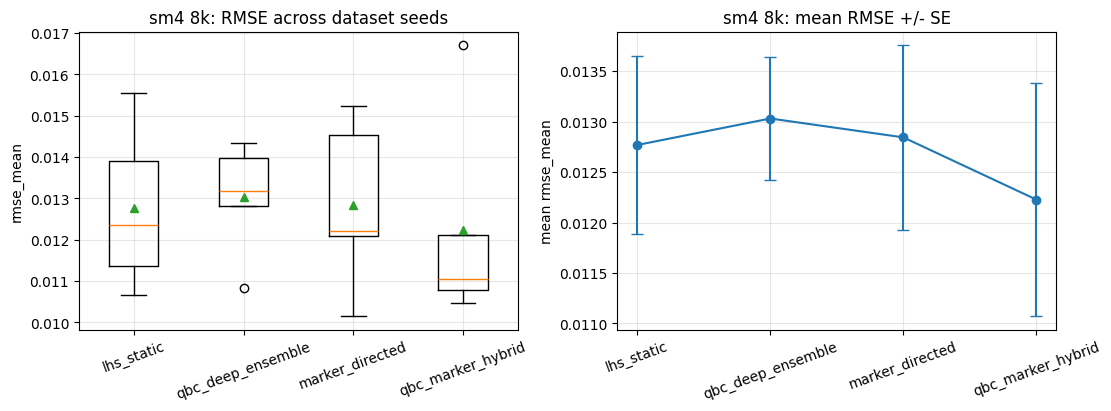

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_23006/1935228623.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(grouped_values, labels=plot_order, showmeans=True)


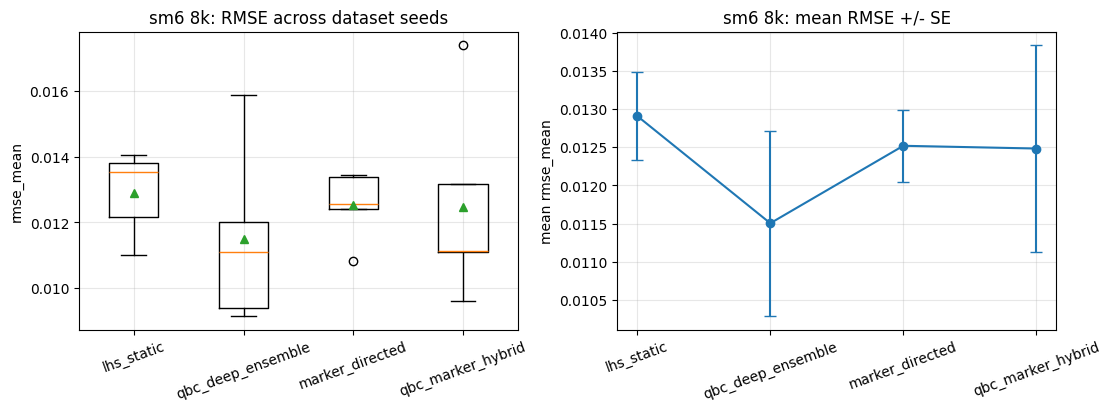

/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_23006/1935228623.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(grouped_values, labels=plot_order, showmeans=True)


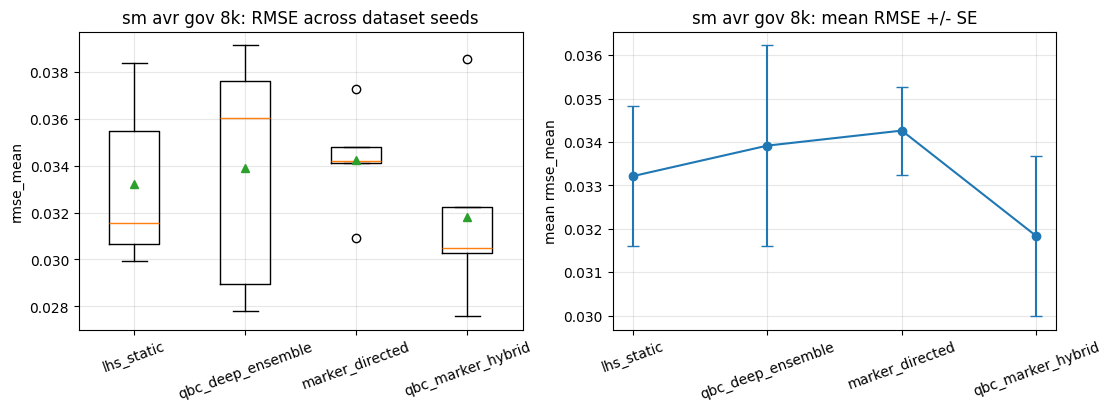

In [5]:
for campaign_name in benchmark_df['campaign_name'].drop_duplicates():
    sub = benchmark_df[benchmark_df['campaign_name'] == campaign_name].copy()
    summary = (
        sub.groupby('method', dropna=False)['rmse_mean']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    summary['se'] = summary['std'] / np.sqrt(summary['count'])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    plot_order = [m for m in METHOD_ORDER if m in sub['method'].astype(str).unique()]
    grouped_values = [sub.loc[sub['method'].astype(str) == method, 'rmse_mean'].to_numpy() for method in plot_order]
    axes[0].boxplot(grouped_values, labels=plot_order, showmeans=True)
    axes[0].set_title(f"{pretty_campaign_label(campaign_name)}: RMSE across dataset seeds")
    axes[0].set_ylabel('rmse_mean')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].grid(alpha=0.3)

    summary = summary.set_index(summary['method'].astype(str)).loc[plot_order].reset_index(drop=True)
    axes[1].errorbar(plot_order, summary['mean'], yerr=summary['se'], fmt='o-', capsize=4)
    axes[1].set_title(f"{pretty_campaign_label(campaign_name)}: mean RMSE +/- SE")
    axes[1].set_ylabel('mean rmse_mean')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(alpha=0.3)

    plt.show()

## Cross-Campaign Comparison

This compares methods across systems using campaign-level mean RMSE. The second table shows relative improvement against `lhs_static`, so positive values mean a method beats the static baseline.

In [6]:
cross_campaign_rmse = (
    campaign_method_summary.pivot(index='campaign_label', columns='method', values='rmse_mean')
    .reindex(columns=[m for m in METHOD_ORDER if m in campaign_method_summary['method'].astype(str).unique()])
)
display(cross_campaign_rmse.round(6))

relative_to_lhs = cross_campaign_rmse.copy()
if 'lhs_static' in relative_to_lhs.columns:
    lhs = relative_to_lhs['lhs_static']
    for col in relative_to_lhs.columns:
        relative_to_lhs[col] = (lhs - relative_to_lhs[col]) / lhs
display(relative_to_lhs.round(4))

cross_campaign_mse = (
    campaign_method_summary.pivot(index='campaign_label', columns='method', values='mse_mean')
    .reindex(columns=[m for m in METHOD_ORDER if m in campaign_method_summary['method'].astype(str).unique()])
)
display(cross_campaign_mse.round(8))

relative_mse_to_lhs = cross_campaign_mse.copy()
if 'lhs_static' in relative_mse_to_lhs.columns:
    lhs_mse = relative_mse_to_lhs['lhs_static']
    for col in relative_mse_to_lhs.columns:
        relative_mse_to_lhs[col] = (lhs_mse - relative_mse_to_lhs[col]) / lhs_mse
display(relative_mse_to_lhs.round(4))


method,lhs_static,qbc_deep_ensemble,marker_directed,qbc_marker_hybrid
campaign_label,,,,
sm avr gov 8k,0.033213,0.033917,0.034263,0.031832
sm4 8k,0.012768,0.013031,0.012844,0.012227
sm6 8k,0.012910,0.011505,0.012520,0.012484


method,lhs_static,qbc_deep_ensemble,marker_directed,qbc_marker_hybrid
campaign_label,,,,
sm avr gov 8k,0.0,-0.0212,-0.0316,0.0416
sm4 8k,0.0,-0.0206,-0.0059,0.0424
sm6 8k,0.0,0.1088,0.0302,0.0330


method,lhs_static,qbc_deep_ensemble,marker_directed,qbc_marker_hybrid
campaign_label,,,,
sm avr gov 8k,0.001138,0.001234,0.001244,0.001081
sm4 8k,0.000169,0.000177,0.000174,0.000161
sm6 8k,0.000172,0.000143,0.000164,0.000178


method,lhs_static,qbc_deep_ensemble,marker_directed,qbc_marker_hybrid
campaign_label,,,,
sm avr gov 8k,0.0,-0.0847,-0.0939,0.0495
sm4 8k,0.0,-0.0445,-0.0270,0.0494
sm6 8k,0.0,0.1681,0.0458,-0.0342


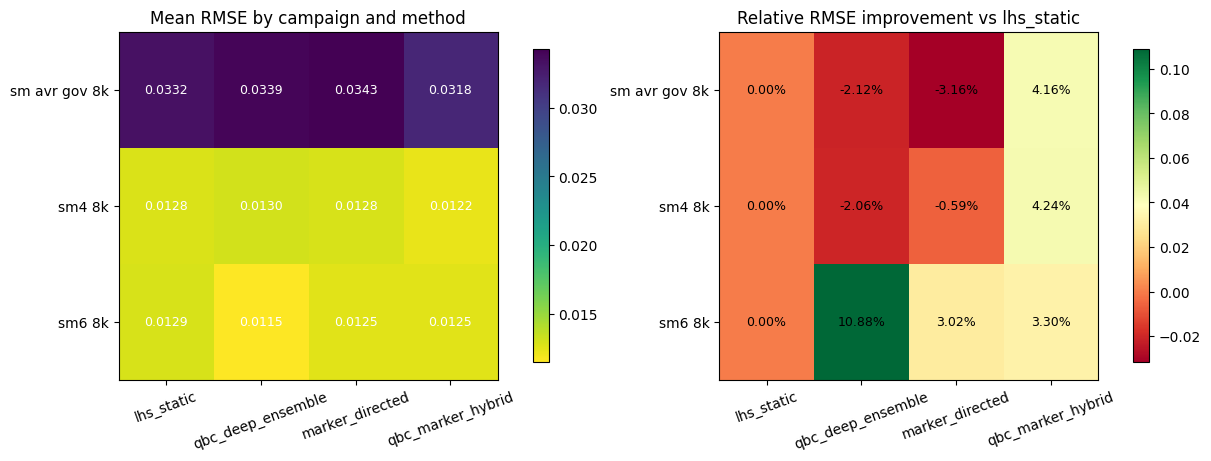

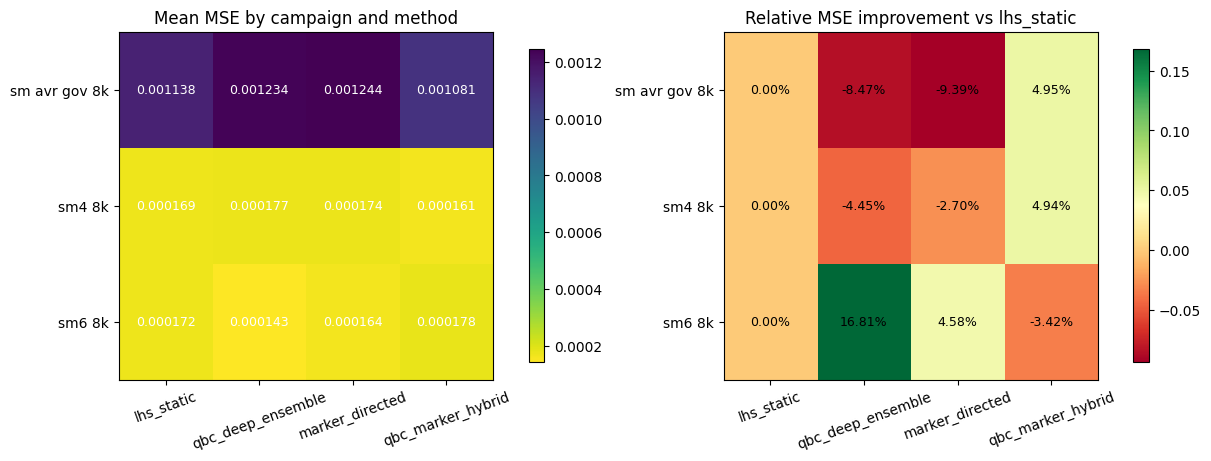

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

im0 = axes[0].imshow(cross_campaign_rmse.to_numpy(dtype=float), cmap='viridis_r', aspect='auto')
axes[0].set_xticks(range(len(cross_campaign_rmse.columns)), [str(c) for c in cross_campaign_rmse.columns], rotation=20)
axes[0].set_yticks(range(len(cross_campaign_rmse.index)), [str(i) for i in cross_campaign_rmse.index])
axes[0].set_title('Mean RMSE by campaign and method')
for y in range(len(cross_campaign_rmse.index)):
    for x in range(len(cross_campaign_rmse.columns)):
        axes[0].text(x, y, f"{cross_campaign_rmse.iloc[y, x]:.4f}", ha='center', va='center', color='white', fontsize=9)
fig.colorbar(im0, ax=axes[0], shrink=0.9)

im1 = axes[1].imshow(relative_to_lhs.to_numpy(dtype=float), cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(len(relative_to_lhs.columns)), [str(c) for c in relative_to_lhs.columns], rotation=20)
axes[1].set_yticks(range(len(relative_to_lhs.index)), [str(i) for i in relative_to_lhs.index])
axes[1].set_title('Relative RMSE improvement vs lhs_static')
for y in range(len(relative_to_lhs.index)):
    for x in range(len(relative_to_lhs.columns)):
        axes[1].text(x, y, f"{relative_to_lhs.iloc[y, x]:.2%}", ha='center', va='center', color='black', fontsize=9)
fig.colorbar(im1, ax=axes[1], shrink=0.9)

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

im0 = axes[0].imshow(cross_campaign_mse.to_numpy(dtype=float), cmap='viridis_r', aspect='auto')
axes[0].set_xticks(range(len(cross_campaign_mse.columns)), [str(c) for c in cross_campaign_mse.columns], rotation=20)
axes[0].set_yticks(range(len(cross_campaign_mse.index)), [str(i) for i in cross_campaign_mse.index])
axes[0].set_title('Mean MSE by campaign and method')
for y in range(len(cross_campaign_mse.index)):
    for x in range(len(cross_campaign_mse.columns)):
        axes[0].text(x, y, f"{cross_campaign_mse.iloc[y, x]:.6f}", ha='center', va='center', color='white', fontsize=9)
fig.colorbar(im0, ax=axes[0], shrink=0.9)

im1 = axes[1].imshow(relative_mse_to_lhs.to_numpy(dtype=float), cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(len(relative_mse_to_lhs.columns)), [str(c) for c in relative_mse_to_lhs.columns], rotation=20)
axes[1].set_yticks(range(len(relative_mse_to_lhs.index)), [str(i) for i in relative_mse_to_lhs.index])
axes[1].set_title('Relative MSE improvement vs lhs_static')
for y in range(len(relative_mse_to_lhs.index)):
    for x in range(len(relative_mse_to_lhs.columns)):
        axes[1].text(x, y, f"{relative_mse_to_lhs.iloc[y, x]:.2%}", ha='center', va='center', color='black', fontsize=9)
fig.colorbar(im1, ax=axes[1], shrink=0.9)

plt.show()


## Robustness View

This separates two types of variation: variation across dataset seeds and the mean baseline-seed spread already reported in the metrics CSV.

,campaign_label,method,rmse_std_across_dataset_seeds,baseline_rmse_std_mean
0,sm4 8k,lhs_static,0.001972,0.002043
1,sm4 8k,qbc_deep_ensemble,0.001367,0.002685
2,sm4 8k,marker_directed,0.002042,0.002623
3,sm4 8k,qbc_marker_hybrid,0.002579,0.002431
4,sm6 8k,lhs_static,0.001294,0.002424
5,sm6 8k,qbc_deep_ensemble,0.002718,0.001954
6,sm6 8k,marker_directed,0.001060,0.002573
7,sm6 8k,qbc_marker_hybrid,0.003028,0.003817
8,sm avr gov 8k,lhs_static,0.003598,0.005871
9,sm avr gov 8k,qbc_deep_ensemble,0.005176,0.009277


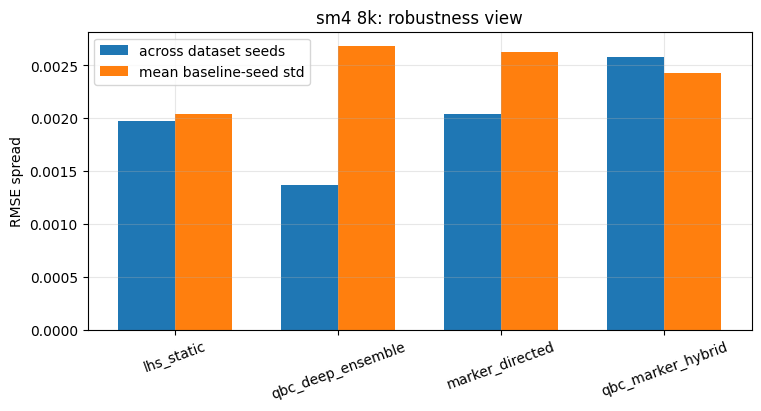

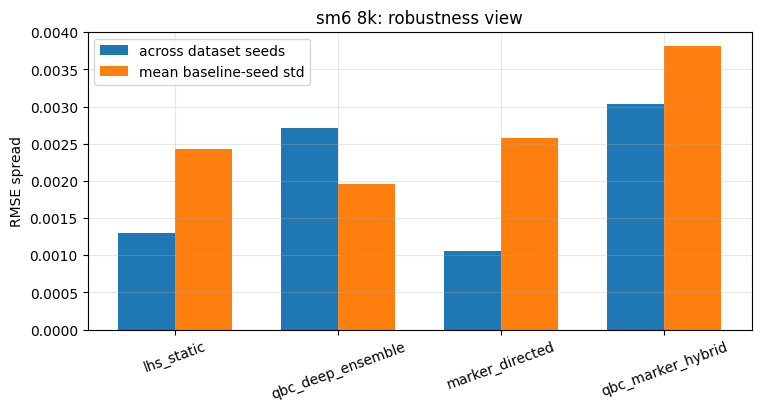

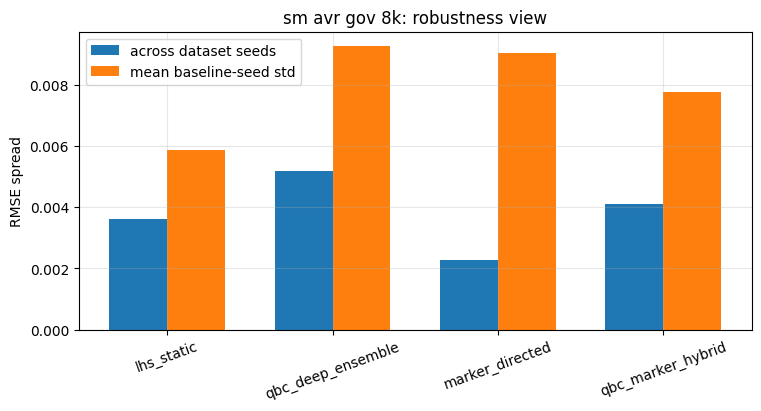

In [8]:
robustness_table = campaign_method_summary[
    ['campaign_label', 'method', 'rmse_std_across_dataset_seeds', 'baseline_rmse_std_mean']
].copy().round(6)
display(robustness_table)

for campaign_name in campaign_method_summary['campaign_name'].drop_duplicates():
    sub = campaign_method_summary[campaign_method_summary['campaign_name'] == campaign_name].copy()
    plot_order = [m for m in METHOD_ORDER if m in sub['method'].astype(str).unique()]
    sub = sub.set_index(sub['method'].astype(str)).loc[plot_order].reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
    x = np.arange(len(plot_order))
    w = 0.35
    ax.bar(x - w / 2, sub['rmse_std_across_dataset_seeds'], width=w, label='across dataset seeds')
    ax.bar(x + w / 2, sub['baseline_rmse_std_mean'], width=w, label='mean baseline-seed std')
    ax.set_xticks(x, plot_order, rotation=20)
    ax.set_title(f"{pretty_campaign_label(campaign_name)}: robustness view")
    ax.set_ylabel('RMSE spread')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

## Short Readout

Use the per-campaign tables to identify the best method within each system. Use the cross-campaign heatmaps to see whether those rankings are consistent across systems, and use the robustness view to judge whether gains are stable across dataset seeds or mostly depend on dataset selection.